# Design and Performance Evaluation of a Differentially Private Federated Learning Framework for Privacy-Preserving Smart City IoT Analytics


In [86]:
# The notebook is importing the libraries being used throughout the practical work
import os
import time
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 110
})

print("Environment is ready")

Environment is ready


In [87]:
Data_FILES = [
    "trafficData158324.csv", "trafficData158386.csv", "trafficData158536.csv",
    "trafficData158655.csv", "trafficData178548.csv", "trafficData178821.csv",
    "trafficData178929.csv", "trafficData179038.csv", "trafficData179148.csv",
    "trafficData179202.csv", "trafficData180601.csv", "trafficData180872.csv"
]

DATA_DIR = Path("/content")
missing = [f for f in Data_FILES if not (DATA_DIR / f).exists()]

if missing:
    from google.colab import files
    print("The following files are being requested:")
    print(*missing, sep="\n")
    uploaded = files.upload()
    for name, content in uploaded.items():
        with open(DATA_DIR / name, "wb") as handle:
            handle.write(content)

missing = [f for f in Data_FILES if not (DATA_DIR / f).exists()]
assert not missing, f"Missing files: {missing}"
print(f"All {len(Data_FILES)} selected traffic clients are available")

All 12 selected traffic clients are available


In [88]:
# The client metadata is being recorded so that the same local reference speed is being used when labels are generated
CLIENT_NDT = {
    "trafficData158324.csv": 71, "trafficData158386.csv": 70,
    "trafficData158536.csv": 109, "trafficData158655.csv": 110,
    "trafficData178548.csv": 48, "trafficData178821.csv": 38,
    "trafficData178929.csv": 27, "trafficData179038.csv": 36,
    "trafficData179148.csv": 53, "trafficData179202.csv": 33,
    "trafficData180601.csv": 52, "trafficData180872.csv": 40
}

CLIENT_INFO = {
    "trafficData158324.csv": {"extID": 160, "report": "AAR_BT_0001"},
    "trafficData158386.csv": {"extID": 162, "report": "AAR_BT_0003"},
    "trafficData158536.csv": {"extID": 167, "report": "AAR_BT_0008"},
    "trafficData158655.csv": {"extID": 171, "report": "AAR_BT_0012"},
    "trafficData178548.csv": {"extID": 193, "report": "AAR_BT_0100"},
    "trafficData178821.csv": {"extID": 199, "report": "AAR_BT_0106"},
    "trafficData178929.csv": {"extID": 203, "report": "AAR_BT_0110"},
    "trafficData179038.csv": {"extID": 207, "report": "AAR_BT_0114"},
    "trafficData179148.csv": {"extID": 211, "report": "AAR_BT_0118"},
    "trafficData179202.csv": {"extID": 213, "report": "AAR_BT_0120"},
    "trafficData180601.csv": {"extID": 225, "report": "AAR_BT_0132"},
    "trafficData180872.csv": {"extID": 235, "report": "AAR_BT_0142"}
}

CLASS_NAMES = {0: "Congested", 1: "Moderate", 2: "Free flow"}
print("Client metadata is ready")

Client metadata is ready


In [89]:
# The raw files are being inspected before any modelling transformations are being applied
raw_frames = {}
summary_rows = []

for filename in Data_FILES:
    frame = pd.read_csv(DATA_DIR / filename)
    raw_frames[filename] = frame
    summary_rows.append({
        "client": filename.replace("trafficData", "").replace(".csv", ""),
        "rows": len(frame),
        "columns": len(frame.columns),
        "duplicates": int(frame.duplicated().sum()),
        "missing_values": int(frame.isna().sum().sum()),
        "start": frame["TIMESTAMP"].min(),
        "end": frame["TIMESTAMP"].max()
    })

raw_summary = pd.DataFrame(summary_rows)
raw_summary

,client,rows,columns,duplicates,missing_values,start,end
0,158324,32075,9,16,0,2014-02-13T11:30:00,2014-06-09T05:35:00
1,158386,28727,9,2,0,2014-02-13T11:30:00,2014-06-09T05:35:00
2,158536,32030,9,16,0,2014-02-13T11:30:00,2014-06-09T05:35:00
3,158655,29178,9,3,0,2014-02-13T11:30:00,2014-06-09T05:35:00
4,178548,31977,9,16,0,2014-02-13T11:30:00,2014-06-09T05:35:00
5,178821,29604,9,5,0,2014-02-13T11:30:00,2014-06-09T05:35:00
6,178929,31967,9,16,0,2014-02-13T11:30:00,2014-06-09T05:35:00
7,179038,27501,9,0,0,2014-02-13T11:30:00,2014-06-09T05:35:00
8,179148,28356,9,2,0,2014-02-13T11:30:00,2014-06-09T05:35:00
9,179202,32009,9,16,0,2014-02-13T11:30:00,2014-06-09T05:35:00


In [90]:
# The common schema and raw data types are being displayed for a direct data quality check
schema = pd.DataFrame({
    "column": raw_frames[Data_FILES[0]].columns,
    "dtype": [str(t) for t in raw_frames[Data_FILES[0]].dtypes],
    "missing": [int(raw_frames[Data_FILES[0]][c].isna().sum()) for c in raw_frames[Data_FILES[0]].columns],
    "unique": [int(raw_frames[Data_FILES[0]][c].nunique()) for c in raw_frames[Data_FILES[0]].columns]
})
schema

,column,dtype,missing,unique
0,status,object,0,1
1,avgMeasuredTime,int64,0,209
2,avgSpeed,int64,0,80
3,extID,int64,0,1
4,medianMeasuredTime,int64,0,209
5,TIMESTAMP,object,0,32059
6,vehicleCount,int64,0,37
7,_id,int64,0,32059
8,REPORT_ID,int64,0,1


In [91]:
# The traffic measurements are being summarised across the twelve clients
traffic_stats = []
for filename, frame in raw_frames.items():
    traffic_stats.append({
        "client": filename.replace("trafficData", "").replace(".csv", ""),
        "avg_speed_mean": frame["avgSpeed"].mean(),
        "avg_speed_min": frame["avgSpeed"].min(),
        "avg_speed_max": frame["avgSpeed"].max(),
        "vehicle_count_mean": frame["vehicleCount"].mean(),
        "travel_time_mean": frame["avgMeasuredTime"].mean(),
        "median_time_mean": frame["medianMeasuredTime"].mean(),
        "status_values": frame["status"].nunique()
    })
pd.DataFrame(traffic_stats).round(2)

,client,avg_speed_mean,avg_speed_min,avg_speed_max,vehicle_count_mean,travel_time_mean,median_time_mean,status_values
0,158324,61.10,0,132,4.30,62.84,62.84,1
1,158386,61.21,20,148,3.28,173.81,173.81,1
2,158536,89.15,16,142,6.94,132.26,132.26,1
3,158655,106.38,33,149,6.71,229.03,229.03,1
4,178548,42.91,0,130,8.34,71.78,71.78,1
5,178821,41.58,0,96,2.39,73.66,73.66,1
6,178929,21.30,0,82,1.86,261.48,261.48,1
7,179038,45.70,5,144,9.55,33.04,33.04,1
8,179148,56.17,12,142,3.95,56.38,56.38,1
9,179202,38.35,5,147,4.37,64.49,64.49,1


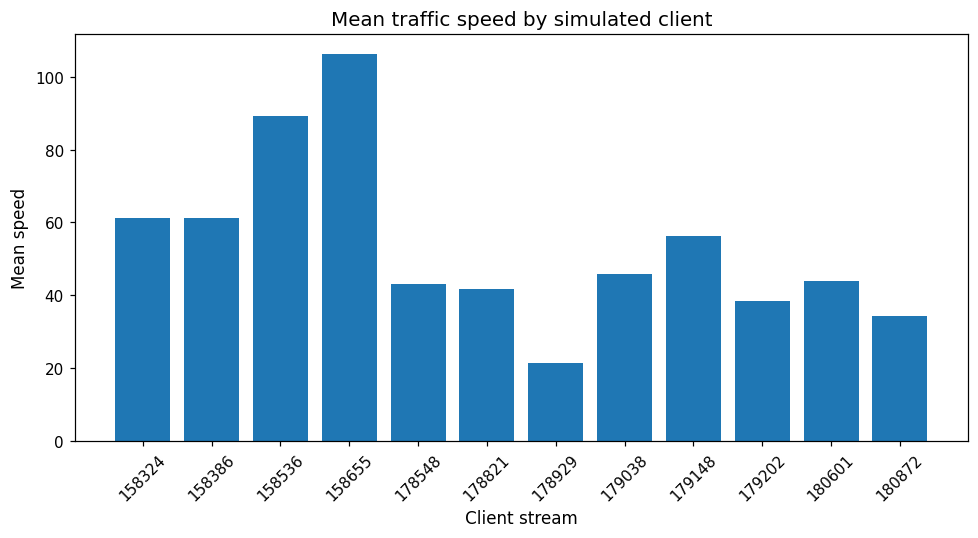

In [92]:
# The client traffic speed distributions are being compared to show the variation between simulated IoT clients
plt.figure()
means = [raw_frames[f]["avgSpeed"].mean() for f in Data_FILES]
labels = [f.replace("trafficData", "").replace(".csv", "") for f in Data_FILES]
plt.bar(labels, means)
plt.xticks(rotation=45)
plt.ylabel("Mean speed")
plt.xlabel("Client stream")
plt.title("Mean traffic speed by simulated client")
plt.tight_layout()
plt.show()

In [93]:
# The local preprocessing function is creating a forecasting style classification target and lagged predictors
def prepare_client(frame, ndt):
    df = frame.copy()
    df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], errors="coerce")
    df = df.dropna(subset=["TIMESTAMP"]).drop_duplicates().sort_values("TIMESTAMP").reset_index(drop=True)

    ratio = df["avgSpeed"] / float(ndt)
    df["speed_ratio"] = ratio.replace([np.inf, -np.inf], np.nan)
    df["target"] = np.select(
        [df["speed_ratio"] < 0.70, df["speed_ratio"] < 0.90],
        [0, 1],
        default=2
    ).astype(int)

    gap = df["TIMESTAMP"].diff().dt.total_seconds()
    valid_previous = gap.le(600)

    for col in ["avgSpeed", "avgMeasuredTime", "medianMeasuredTime", "vehicleCount"]:
        df[f"{col}_lag1"] = df[col].shift(1).where(valid_previous)

    gap2 = df["TIMESTAMP"].diff(2).dt.total_seconds()
    valid_two_back = gap2.le(900)
    for col in ["avgSpeed", "vehicleCount"]:
        df[f"{col}_lag2"] = df[col].shift(2).where(valid_two_back)

    minutes = df["TIMESTAMP"].dt.hour * 60 + df["TIMESTAMP"].dt.minute
    df["hour_sin"] = np.sin(2 * np.pi * minutes / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * minutes / 1440)
    weekday = df["TIMESTAMP"].dt.dayofweek
    df["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

    feature_cols = [
        "avgSpeed_lag1", "avgSpeed_lag2",
        "avgMeasuredTime_lag1", "medianMeasuredTime_lag1",
        "vehicleCount_lag1", "vehicleCount_lag2",
        "hour_sin", "hour_cos", "weekday_sin", "weekday_cos"
    ]

    model_df = df[["TIMESTAMP", "target"] + feature_cols].dropna().reset_index(drop=True)
    return model_df, feature_cols, df

prepared = {}
quality_rows = []
for filename in Data_FILES:
    model_df, feature_cols, full_df = prepare_client(raw_frames[filename], CLIENT_NDT[filename])
    prepared[filename] = model_df
    quality_rows.append({
        "client": filename.replace("trafficData", "").replace(".csv", ""),
        "usable_rows": len(model_df),
        "class_0": int((model_df.target == 0).sum()),
        "class_1": int((model_df.target == 1).sum()),
        "class_2": int((model_df.target == 2).sum()),
        "target_rate": model_df.target.mean()
    })

quality_table = pd.DataFrame(quality_rows)
quality_table

,client,usable_rows,class_0,class_1,class_2,target_rate
0,158324,31782,2908,17720,11154,1.259455
1,158386,27759,1738,15304,10717,1.323463
2,158536,31737,2099,26236,3402,1.041056
3,158655,28202,84,6475,21643,1.764449
4,178548,31680,9031,9565,13084,1.127936
5,178821,28655,3187,735,24733,1.751911
6,178929,31668,11313,9469,10886,0.986516
7,179038,26685,3630,1398,21657,1.675548
8,179148,27404,1443,6680,19281,1.650927
9,179202,31709,8459,4983,18267,1.309313


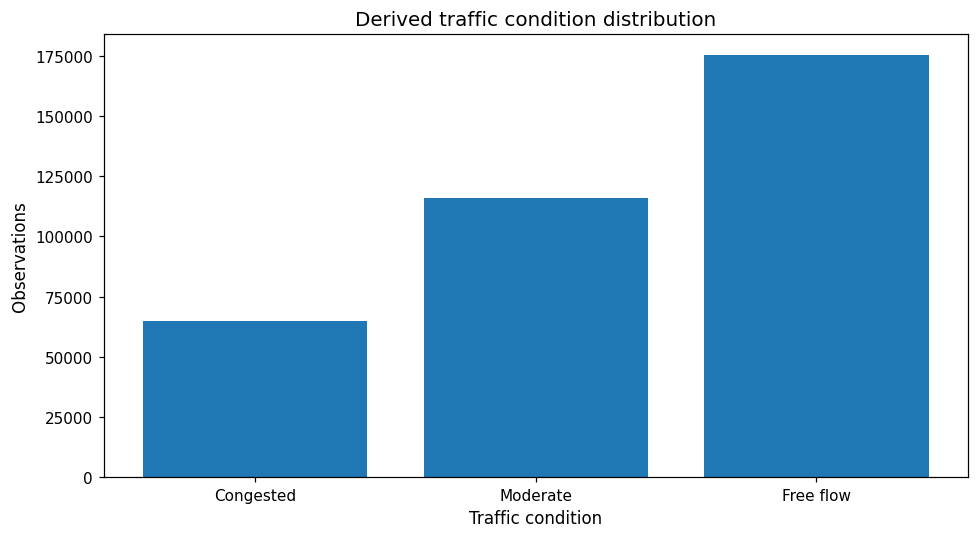

In [94]:
# The derived traffic condition distribution is being visualised for the complete client population
combined_target = pd.concat([df["target"] for df in prepared.values()], ignore_index=True)
counts = combined_target.value_counts().sort_index()

plt.figure()
plt.bar([CLASS_NAMES[i] for i in counts.index], counts.values)
plt.ylabel("Observations")
plt.xlabel("Traffic condition")
plt.title("Derived traffic condition distribution")
plt.tight_layout()
plt.show()

In [95]:
# The time split function is keeping future observations out of the training data
def split_client(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    train = df.iloc[:train_end].copy()
    val = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()
    return train, val, test

client_splits = {}
for filename, df in prepared.items():
    client_splits[filename] = split_client(df)

print("Time ordered train, validation and test partitions are being created")
print("Train: 70 percent   Validation: 15 percent   Test: 15 percent")

Time ordered train, validation and test partitions are being created
Train: 70 percent   Validation: 15 percent   Test: 15 percent


In [96]:
# The local standardisation function is fitting scaling parameters only on each client's training partition
def scale_client_splits(splits, feature_cols):
    scaled = {}
    for filename, (train, val, test) in splits.items():
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train[feature_cols]).astype(np.float32)
        x_val = scaler.transform(val[feature_cols]).astype(np.float32)
        x_test = scaler.transform(test[feature_cols]).astype(np.float32)
        scaled[filename] = {
            "X_train": x_train, "y_train": train.target.to_numpy(dtype=np.int64),
            "X_val": x_val, "y_val": val.target.to_numpy(dtype=np.int64),
            "X_test": x_test, "y_test": test.target.to_numpy(dtype=np.int64),
            "scaler": scaler
        }
    return scaled

scaled_clients = scale_client_splits(client_splits, feature_cols)
INPUT_DIM = len(feature_cols)
NUM_CLASSES = 3
print(f"The model is receiving {INPUT_DIM} locally standardised features")

The model is receiving 10 locally standardised features


In [97]:
# The class weights are being calculated from each client's training partition to reduce the effect of local class imbalance
client_weights = {}
for filename, data in scaled_clients.items():
    classes_present = np.unique(data["y_train"])
    weights = compute_class_weight("balanced", classes=classes_present, y=data["y_train"])
    client_weights[filename] = {int(c): float(w) for c, w in zip(classes_present, weights)}
print("Local class weights are ready")

Local class weights are ready


## Centralized baseline

In [98]:
# The centralized baseline is being trained on pooled training data while validation and test data are remaining separate
X_central_train = np.vstack([v["X_train"] for v in scaled_clients.values()])
y_central_train = np.concatenate([v["y_train"] for v in scaled_clients.values()])
X_central_val = np.vstack([v["X_val"] for v in scaled_clients.values()])
y_central_val = np.concatenate([v["y_val"] for v in scaled_clients.values()])
X_central_test = np.vstack([v["X_test"] for v in scaled_clients.values()])
y_central_test = np.concatenate([v["y_test"] for v in scaled_clients.values()])

central_model = LogisticRegression(max_iter=300, multi_class="multinomial", class_weight="balanced", random_state=SEED)
central_start = time.perf_counter()
central_model.fit(X_central_train, y_central_train)
central_time = time.perf_counter() - central_start
central_pred = central_model.predict(X_central_test)

def metric_row(name, y_true, y_pred, elapsed=None):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"model": name, "accuracy": accuracy_score(y_true, y_pred), "precision_macro": p, "recall_macro": r, "f1_macro": f, "training_seconds": elapsed if elapsed is not None else np.nan}

central_metrics = metric_row("Centralized ML", y_central_test, central_pred, central_time)
pd.DataFrame([central_metrics]).round(4)

,model,accuracy,precision_macro,recall_macro,f1_macro,training_seconds
0,Centralized ML,0.6079,0.5734,0.612,0.5818,2.5941


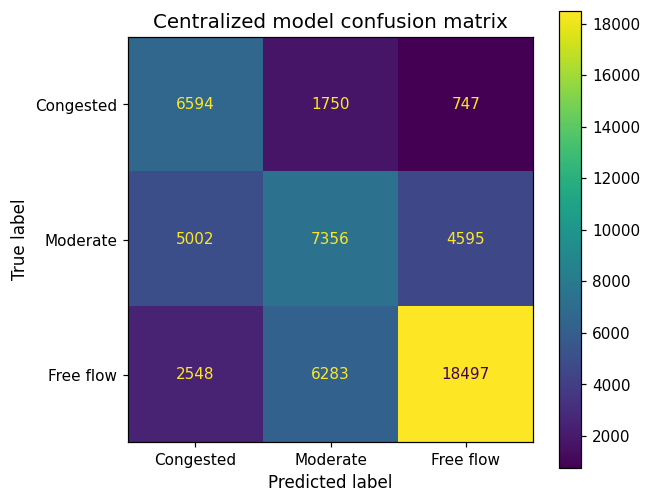

In [99]:
# The centralized confusion matrix is being displayed to show class level performance
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_central_test, central_pred), display_labels=list(CLASS_NAMES.values())).plot(ax=ax, values_format="d")
ax.set_title("Centralized model confusion matrix")
plt.tight_layout()
plt.show()

## Federated learning

In [100]:
# The softmax model is being defined with explicit gradients so that local updates can be clipped and noised for Differential Privacy
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

def init_model(input_dim, classes, seed=SEED):
    rng = np.random.default_rng(seed)
    W = rng.normal(0, 0.02, size=(input_dim, classes)).astype(np.float64)
    b = np.zeros(classes, dtype=np.float64)
    return {"W": W, "b": b}

def copy_model(model):
    return {"W": model["W"].copy(), "b": model["b"].copy()}

def model_vector(model):
    return np.concatenate([model["W"].ravel(), model["b"].ravel()])

def vector_model(vector, input_dim, classes):
    w_size = input_dim * classes
    return {"W": vector[:w_size].reshape(input_dim, classes).copy(), "b": vector[w_size:].reshape(classes).copy()}

def predict_model(model, X):
    return np.argmax(softmax(X @ model["W"] + model["b"]), axis=1)

def local_train(global_model, X, y, class_weights, epochs=1, batch_size=256, lr=0.05, seed=SEED):
    model = copy_model(global_model)
    rng = np.random.default_rng(seed)
    n = len(X)
    indices = np.arange(n)
    for _ in range(epochs):
        rng.shuffle(indices)
        for start in range(0, n, batch_size):
            idx = indices[start:start + batch_size]
            xb = X[idx]
            yb = y[idx]
            probs = softmax(xb @ model["W"] + model["b"])
            weights = np.array([class_weights[int(label)] for label in yb])
            one_hot = np.zeros_like(probs)
            one_hot[np.arange(len(yb)), yb] = 1.0
            error = (probs - one_hot) * weights[:, None]
            error /= max(weights.sum(), 1.0)
            grad_w = xb.T @ error
            grad_b = error.sum(axis=0)
            model["W"] -= lr * grad_w
            model["b"] -= lr * grad_b
    return model

def clip_update(update, clip_norm):
    norm = np.linalg.norm(update)
    scale = min(1.0, clip_norm / (norm + 1e-12))
    return update * scale, norm, scale

def gaussian_sigma(epsilon, delta, clip_norm):
    return clip_norm * math.sqrt(2 * math.log(1.25 / delta)) / epsilon

def evaluate_model(model, X, y):
    pred = predict_model(model, X)
    p, r, f, _ = precision_recall_fscore_support(y, pred, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y, pred), "precision_macro": p, "recall_macro": r, "f1_macro": f}

PARAMETER_COUNT = INPUT_DIM * NUM_CLASSES + NUM_CLASSES
print(f"The federated model is containing {PARAMETER_COUNT} trainable parameters")

The federated model is containing 33 trainable parameters


In [101]:
# The federated training loop is being implemented with weighted FedAvg over the twelve local clients
def run_federated(epsilon_total=None, rounds=5, local_epochs=1, lr=0.05, batch_size=256, clip_norm=1.0, delta=1e-5, seed=SEED):
    global_model = init_model(INPUT_DIM, NUM_CLASSES, seed=seed)
    history = []
    client_update_records = []
    start_all = time.perf_counter()
    epsilon_round = None if epsilon_total is None else epsilon_total / rounds

    for round_id in range(1, rounds + 1):
        round_start = time.perf_counter()
        updates = []
        weights = []

        for client_index, filename in enumerate(Data_FILES):
            data = scaled_clients[filename]
            local_start = time.perf_counter()
            local_model = local_train(
                global_model, data["X_train"], data["y_train"], client_weights[filename],
                epochs=local_epochs, batch_size=batch_size, lr=lr,
                seed=seed + round_id * 100 + client_index
            )
            local_time = time.perf_counter() - local_start
            raw_update = model_vector(local_model) - model_vector(global_model)
            clipped_update, raw_norm, clip_scale = clip_update(raw_update, clip_norm)

            noise_std = 0.0
            if epsilon_round is not None:
                noise_std = gaussian_sigma(epsilon_round, delta, clip_norm)
                rng = np.random.default_rng(seed + round_id * 1000 + client_index)
                clipped_update = clipped_update + rng.normal(0, noise_std, size=clipped_update.shape)

            updates.append(clipped_update)
            weights.append(len(data["X_train"]))
            client_update_records.append({
                "round": round_id, "client": filename, "raw_update_norm": raw_norm,
                "clip_scale": clip_scale, "noise_std": noise_std, "local_seconds": local_time
            })

        weights = np.asarray(weights, dtype=np.float64)
        weights = weights / weights.sum()
        aggregate = np.sum(np.stack(updates) * weights[:, None], axis=0)
        global_model = vector_model(model_vector(global_model) + aggregate, INPUT_DIM, NUM_CLASSES)

        test_metrics = evaluate_model(global_model, X_central_test, y_central_test)
        val_metrics = evaluate_model(global_model, X_central_val, y_central_val)
        round_time = time.perf_counter() - round_start
        history.append({
            "round": round_id,
            "accuracy": test_metrics["accuracy"],
            "precision_macro": test_metrics["precision_macro"],
            "recall_macro": test_metrics["recall_macro"],
            "f1_macro": test_metrics["f1_macro"],
            "validation_f1": val_metrics["f1_macro"],
            "round_seconds": round_time,
            "epsilon_total": None if epsilon_total is None else epsilon_round * round_id
        })

    total_time = time.perf_counter() - start_all
    return global_model, pd.DataFrame(history), pd.DataFrame(client_update_records), total_time

fl_model, fl_history, fl_updates, fl_time = run_federated(epsilon_total=None)
fl_metrics = metric_row("Standard Federated Learning", y_central_test, predict_model(fl_model, X_central_test), fl_time)
fl_history.round(4)

,round,accuracy,precision_macro,recall_macro,f1_macro,validation_f1,round_seconds,epsilon_total
0,1,0.5716,0.5307,0.5684,0.5401,0.5517,0.5850,None
1,2,0.5770,0.5440,0.5694,0.5529,0.5664,0.5745,None
2,3,0.5813,0.5535,0.5729,0.5605,0.5728,0.4681,None
3,4,0.5813,0.5552,0.5724,0.5612,0.5748,0.3030,None
4,5,0.5832,0.5603,0.5723,0.5641,0.5772,0.3168,None


In [102]:
# The standard federated learning metrics are being collected for later comparison
fl_metrics

{'model': 'Standard Federated Learning',
 'accuracy': 0.5832458967248745,
 'precision_macro': 0.5602840744662048,
 'recall_macro': 0.5722804214878573,
 'f1_macro': 0.5641373929799879,
 'training_seconds': 2.2474551189999374}

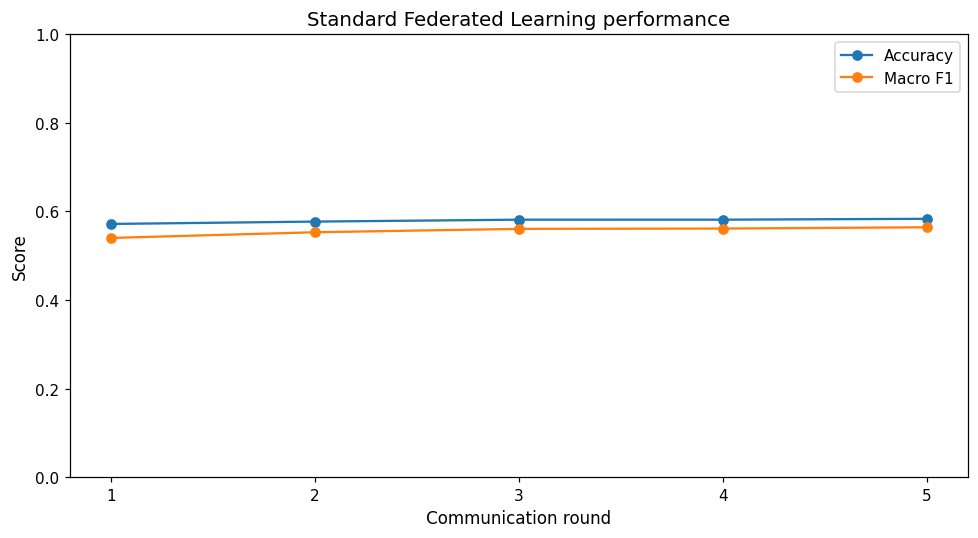

In [103]:
# The standard federated learning learning curve is being plotted across communication rounds
plt.figure()
plt.plot(fl_history["round"], fl_history["accuracy"], marker="o", label="Accuracy")
plt.plot(fl_history["round"], fl_history["f1_macro"], marker="o", label="Macro F1")
plt.xlabel("Communication round")
plt.ylabel("Score")
plt.title("Standard Federated Learning performance")
plt.xticks(fl_history["round"])
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Differentially private federated learning

In [104]:
# The client level DP model is being trained by clipping each local model update and adding Gaussian noise before aggregation
DP_EPSILONS = [0.5, 1.0, 2.0, 4.0, 8.0]
DP_RESULTS = []
dp_runs = {}

for epsilon in DP_EPSILONS:
    dp_model, dp_history, dp_updates, dp_time = run_federated(
        epsilon_total=epsilon, rounds=5, local_epochs=1, lr=0.05,
        batch_size=256, clip_norm=1.0, delta=1e-5, seed=SEED
    )
    dp_runs[epsilon] = {"model": dp_model, "history": dp_history, "updates": dp_updates, "time": dp_time}
    final = evaluate_model(dp_model, X_central_test, y_central_test)
    DP_RESULTS.append({
        "epsilon": epsilon,
        "accuracy": final["accuracy"],
        "precision_macro": final["precision_macro"],
        "recall_macro": final["recall_macro"],
        "f1_macro": final["f1_macro"],
        "training_seconds": dp_time,
        "noise_std_per_round": gaussian_sigma(epsilon / 5, 1e-5, 1.0)
    })

dp_results = pd.DataFrame(DP_RESULTS)
dp_results.round(4)

,epsilon,accuracy,precision_macro,recall_macro,f1_macro,training_seconds,noise_std_per_round
0,0.5,0.3250,0.3012,0.3033,0.2831,1.4670,48.4481
1,1.0,0.3291,0.3095,0.3087,0.2896,1.8941,24.2240
2,2.0,0.3409,0.3296,0.3230,0.3070,2.3581,12.1120
3,4.0,0.3735,0.3749,0.3620,0.3517,1.4628,6.0560
4,8.0,0.4422,0.4467,0.4420,0.4326,1.4985,3.0280


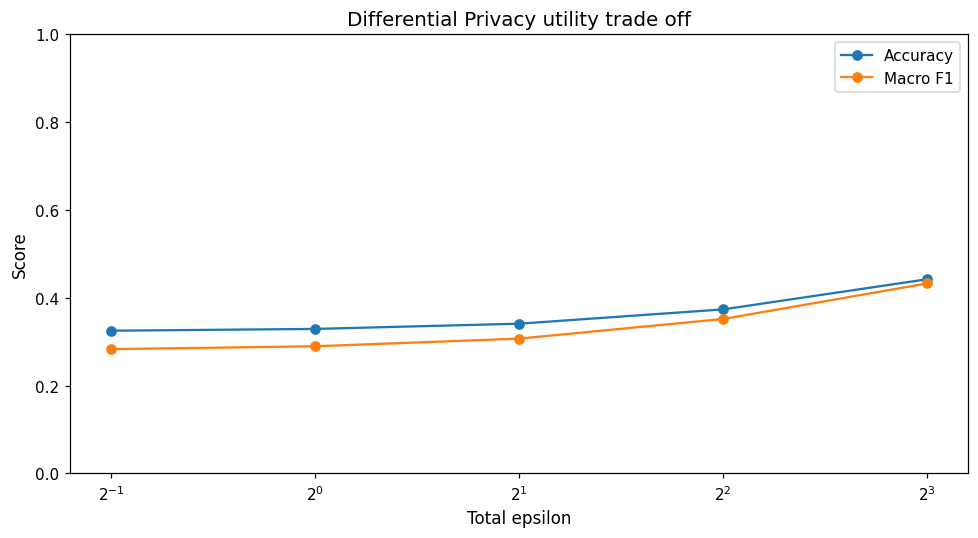

In [105]:
# The privacy utility relationship is being plotted over the tested privacy budgets
plt.figure()
plt.plot(dp_results["epsilon"], dp_results["accuracy"], marker="o", label="Accuracy")
plt.plot(dp_results["epsilon"], dp_results["f1_macro"], marker="o", label="Macro F1")
plt.xlabel("Total epsilon")
plt.ylabel("Score")
plt.title("Differential Privacy utility trade off")
plt.xscale("log", base=2)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

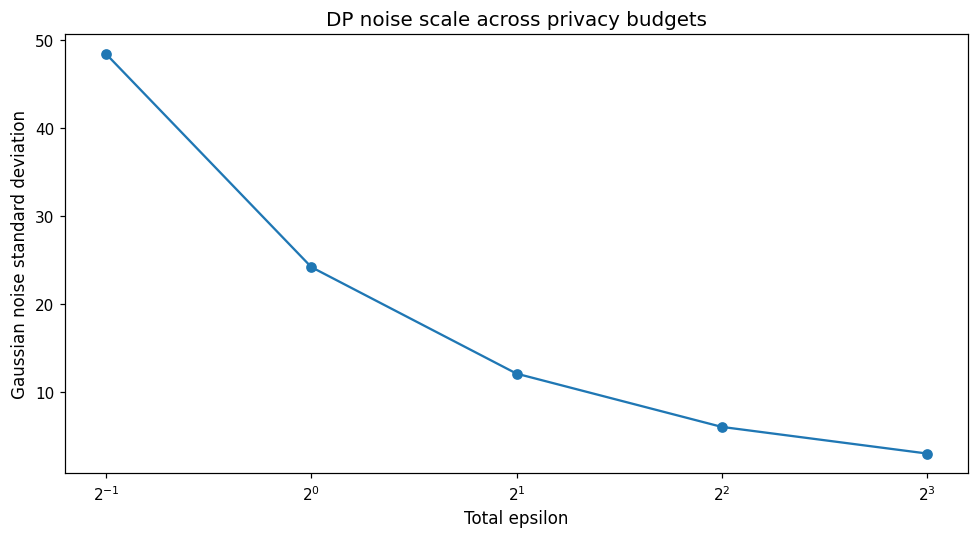

In [106]:
# The privacy noise scale is being visualised against the tested total privacy budgets
plt.figure()
plt.plot(dp_results["epsilon"], dp_results["noise_std_per_round"], marker="o")
plt.xlabel("Total epsilon")
plt.ylabel("Gaussian noise standard deviation")
plt.title("DP noise scale across privacy budgets")
plt.xscale("log", base=2)
plt.tight_layout()
plt.show()

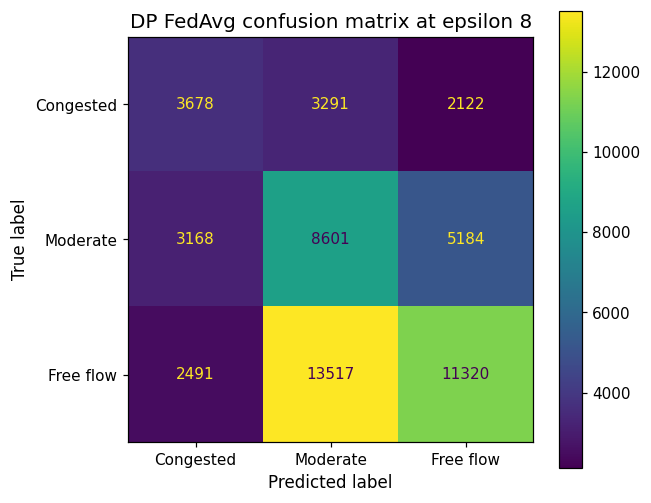

In [107]:
# The final DP model is being selected from the tested privacy budgets using macro F1 as the primary utility measure
best_epsilon = float(dp_results.loc[dp_results["f1_macro"].idxmax(), "epsilon"])
best_dp_model = dp_runs[best_epsilon]["model"]
best_dp_history = dp_runs[best_epsilon]["history"]
best_dp_pred = predict_model(best_dp_model, X_central_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_central_test, best_dp_pred), display_labels=list(CLASS_NAMES.values())).plot(ax=ax, values_format="d")
ax.set_title(f"DP FedAvg confusion matrix at epsilon {best_epsilon:g}")
plt.tight_layout()
plt.show()

## Comparative evaluation

In [108]:
# The main predictive results are being combined into one comparison table
comparison_rows = [central_metrics, fl_metrics]
for row in DP_RESULTS:
    comparison_rows.append({
        "model": f"DP Federated Learning eps={row['epsilon']:g}",
        "accuracy": row["accuracy"],
        "precision_macro": row["precision_macro"],
        "recall_macro": row["recall_macro"],
        "f1_macro": row["f1_macro"],
        "training_seconds": row["training_seconds"]
    })
comparison = pd.DataFrame(comparison_rows)
comparison.round(4)

,model,accuracy,precision_macro,recall_macro,f1_macro,training_seconds
0,Centralized ML,0.6079,0.5734,0.6120,0.5818,2.5941
1,Standard Federated Learning,0.5832,0.5603,0.5723,0.5641,2.2475
2,DP Federated Learning eps=0.5,0.3250,0.3012,0.3033,0.2831,1.4670
3,DP Federated Learning eps=1,0.3291,0.3095,0.3087,0.2896,1.8941
4,DP Federated Learning eps=2,0.3409,0.3296,0.3230,0.3070,2.3581
5,DP Federated Learning eps=4,0.3735,0.3749,0.3620,0.3517,1.4628
6,DP Federated Learning eps=8,0.4422,0.4467,0.4420,0.4326,1.4985


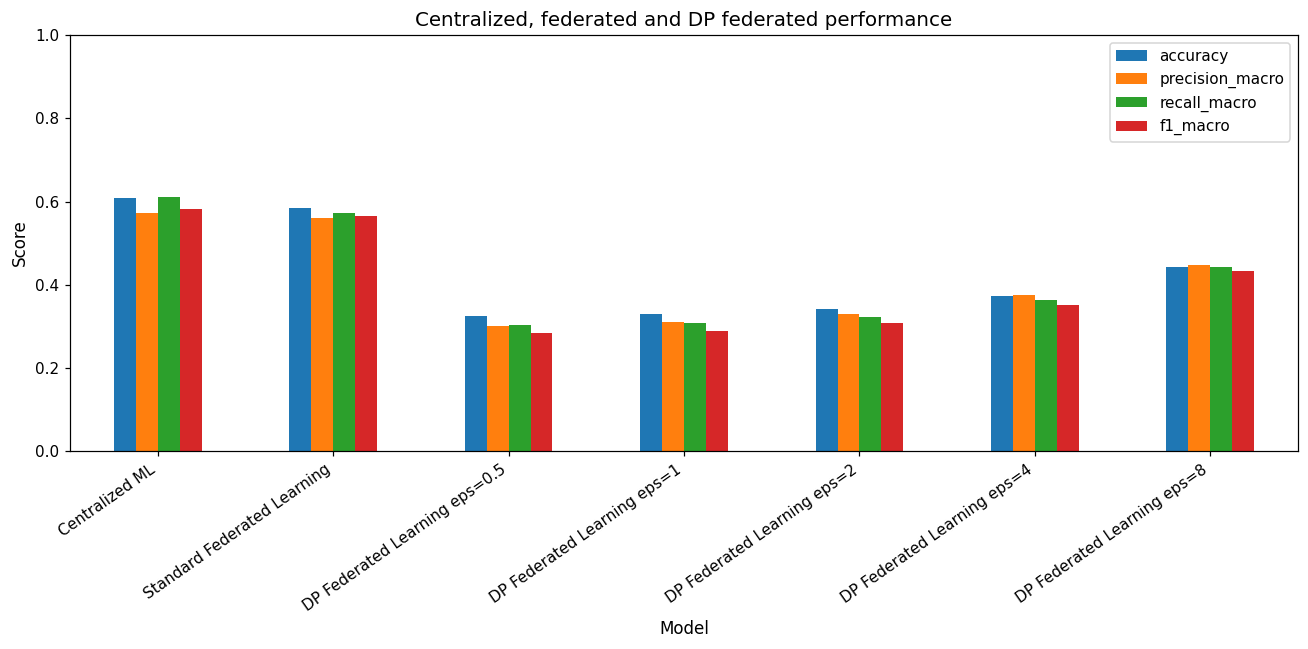

In [109]:
# The model performance comparison is being plotted for the four required predictive metrics
plot_df = comparison.set_index("model")[["accuracy", "precision_macro", "recall_macro", "f1_macro"]]
ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_title("Centralized, federated and DP federated performance")
ax.set_ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

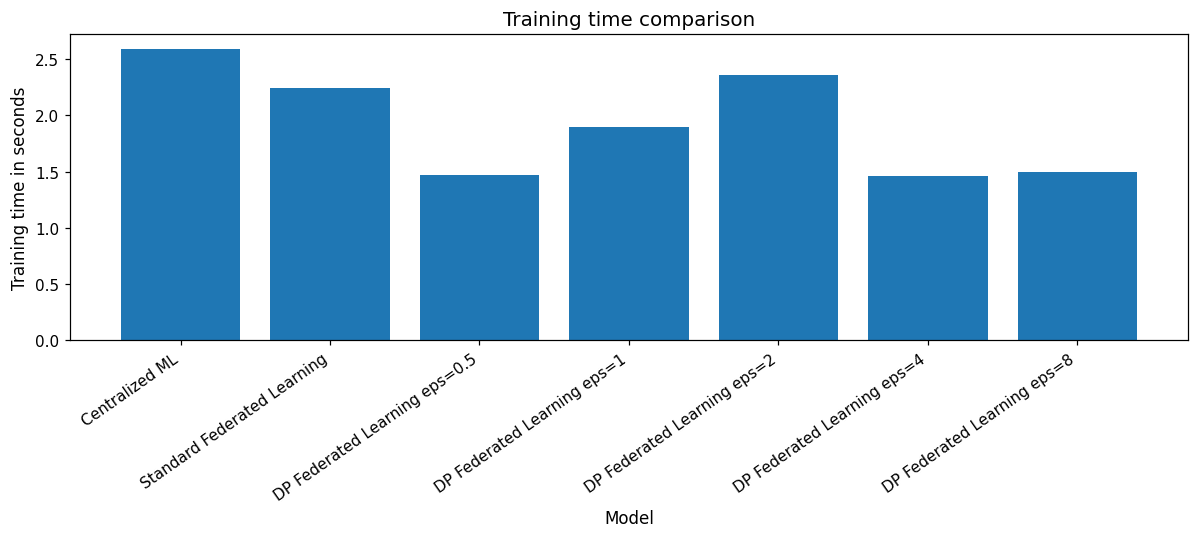

In [110]:
# The training time comparison is being displayed to support the computational efficiency evaluation
plt.figure(figsize=(11, 5))
plt.bar(comparison["model"], comparison["training_seconds"])
plt.ylabel("Training time in seconds")
plt.xlabel("Model")
plt.title("Training time comparison")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [111]:
# The federated communication cost is being estimated from the number of clients, rounds and model parameters
CLIENT_COUNT = len(Data_FILES)
ROUNDS = 5
BYTES_PER_PARAMETER = 8
FL_UPDATE_BYTES = PARAMETER_COUNT * BYTES_PER_PARAMETER
FL_TOTAL_UPLOAD_BYTES = CLIENT_COUNT * ROUNDS * FL_UPDATE_BYTES
FL_TOTAL_MB = FL_TOTAL_UPLOAD_BYTES / (1024 ** 2)

central_records = len(X_central_train)
central_feature_bytes = X_central_train.shape[1] * 8
central_label_bytes = 8
central_estimated_bytes = central_records * (central_feature_bytes + central_label_bytes)
central_estimated_mb = central_estimated_bytes / (1024 ** 2)

communication = pd.DataFrame({
    "approach": ["Centralized raw training data", "Standard FL model updates", "DP FL model updates"],
    "estimated_upload_MB": [central_estimated_mb, FL_TOTAL_MB, FL_TOTAL_MB],
    "clients": [1, CLIENT_COUNT, CLIENT_COUNT],
    "rounds": [1, ROUNDS, ROUNDS],
    "parameters_per_update": [np.nan, PARAMETER_COUNT, PARAMETER_COUNT]
})
communication.round(3)

,approach,estimated_upload_MB,clients,rounds,parameters_per_update
0,Centralized raw training data,20.900,1,1,NaN
1,Standard FL model updates,0.015,12,5,33.0
2,DP FL model updates,0.015,12,5,33.0


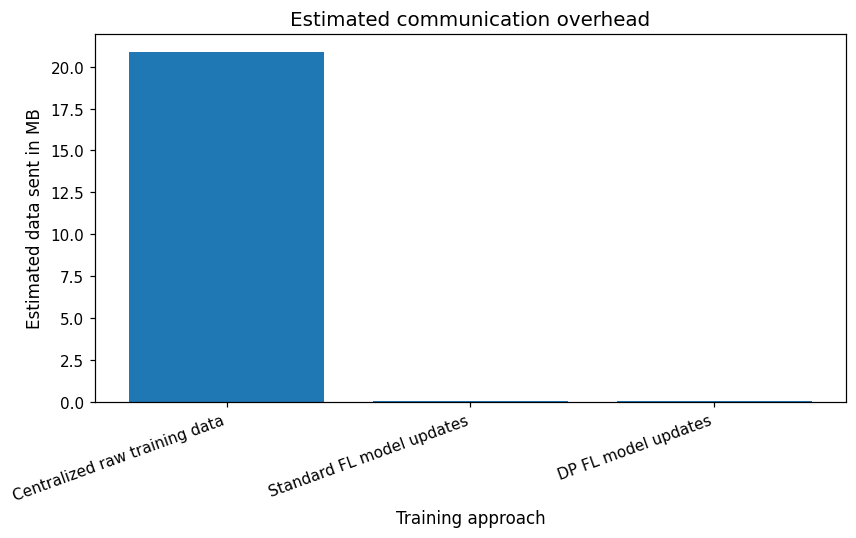

In [112]:
# The communication cost is being visualised to show the difference between transmitting training records and model updates
plt.figure(figsize=(8, 5))
plt.bar(communication["approach"], communication["estimated_upload_MB"])
plt.ylabel("Estimated data sent in MB")
plt.xlabel("Training approach")
plt.title("Estimated communication overhead")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

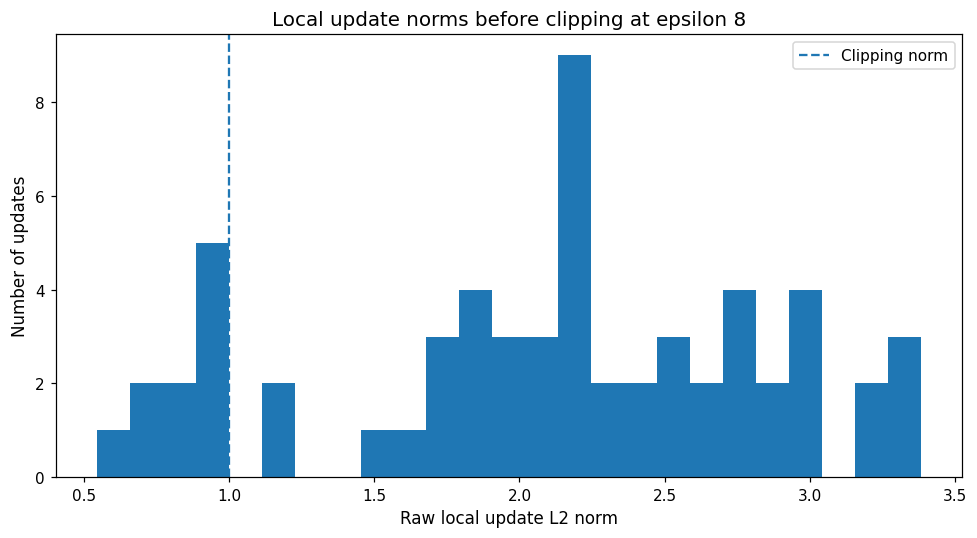

In [113]:
# The client update norms are being plotted before and after clipping for the selected DP experiment
best_updates = dp_runs[best_epsilon]["updates"]
plt.figure()
plt.hist(best_updates["raw_update_norm"], bins=25)
plt.axvline(1.0, linestyle="--", label="Clipping norm")
plt.xlabel("Raw local update L2 norm")
plt.ylabel("Number of updates")
plt.title(f"Local update norms before clipping at epsilon {best_epsilon:g}")
plt.legend()
plt.tight_layout()
plt.show()

In [114]:
# The final privacy utility table is being prepared with the selected epsilon clearly marked
dp_results["selected"] = dp_results["epsilon"].eq(best_epsilon)
dp_results.round(4)

,epsilon,accuracy,precision_macro,recall_macro,f1_macro,training_seconds,noise_std_per_round,selected
0,0.5,0.3250,0.3012,0.3033,0.2831,1.4670,48.4481,False
1,1.0,0.3291,0.3095,0.3087,0.2896,1.8941,24.2240,False
2,2.0,0.3409,0.3296,0.3230,0.3070,2.3581,12.1120,False
3,4.0,0.3735,0.3749,0.3620,0.3517,1.4628,6.0560,False
4,8.0,0.4422,0.4467,0.4420,0.4326,1.4985,3.0280,True


## Client level evaluation

In [115]:
# The best DP model is being evaluated separately on every held out client test partition
client_eval_rows = []
for filename, data in scaled_clients.items():
    pred = predict_model(best_dp_model, data["X_test"])
    metrics = evaluate_model(best_dp_model, data["X_test"], data["y_test"])
    client_eval_rows.append({
        "client": filename.replace("trafficData", "").replace(".csv", ""),
        **metrics
    })

client_evaluation = pd.DataFrame(client_eval_rows)
client_evaluation.round(4)

,client,accuracy,precision_macro,recall_macro,f1_macro
0,158324,0.4434,0.3885,0.4272,0.3961
1,158386,0.4239,0.3663,0.4287,0.3637
2,158536,0.4608,0.3299,0.3451,0.3040
3,158655,0.4748,0.3645,0.4269,0.3099
4,178548,0.5107,0.5746,0.5385,0.5222
5,178821,0.4559,0.3496,0.4938,0.2535
6,178929,0.5060,0.5578,0.5057,0.5160
7,179038,0.3905,0.4363,0.4170,0.3606
8,179148,0.4040,0.3787,0.4444,0.3493
9,179202,0.4171,0.4768,0.4469,0.3954


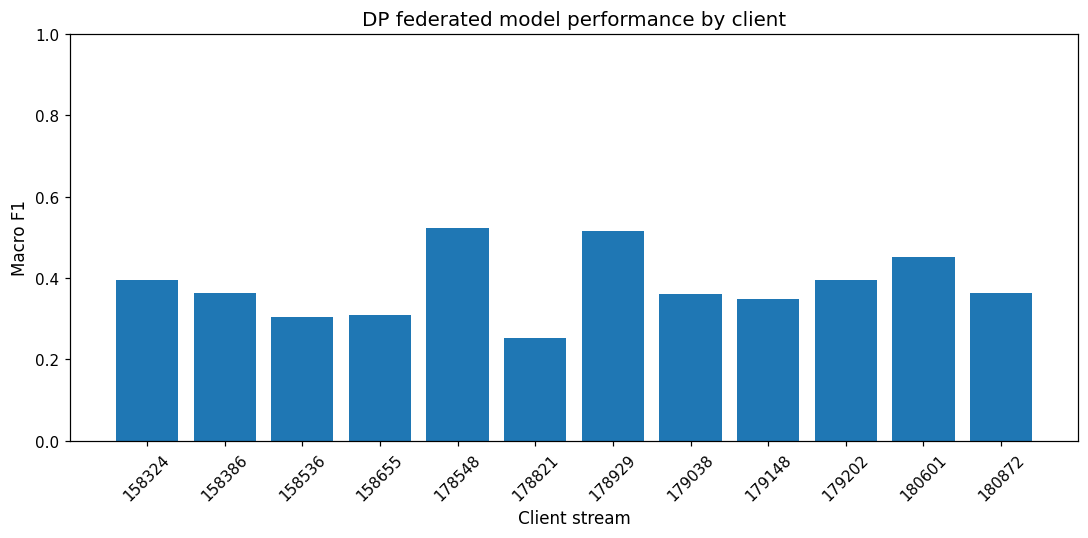

In [116]:
# The client level macro F1 scores are being plotted to show how the global DP model is performing across heterogeneous traffic streams
plt.figure(figsize=(10, 5))
plt.bar(client_evaluation["client"], client_evaluation["f1_macro"])
plt.ylabel("Macro F1")
plt.xlabel("Client stream")
plt.title("DP federated model performance by client")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [117]:
# The final results are being exported
OUTPUT_DIR = Path("/content/fl_results")
OUTPUT_DIR.mkdir(exist_ok=True)

raw_summary.to_csv(OUTPUT_DIR / "raw_data_summary.csv", index=False)
quality_table.to_csv(OUTPUT_DIR / "client_quality_and_target_summary.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
dp_results.to_csv(OUTPUT_DIR / "dp_privacy_utility_results.csv", index=False)
client_evaluation.to_csv(OUTPUT_DIR / "client_level_evaluation.csv", index=False)
communication.to_csv(OUTPUT_DIR / "communication_overhead.csv", index=False)
fl_history.to_csv(OUTPUT_DIR / "standard_fl_history.csv", index=False)
best_dp_history.to_csv(OUTPUT_DIR / "best_dp_fl_history.csv", index=False)
fl_updates.to_csv(OUTPUT_DIR / "standard_fl_client_updates.csv", index=False)
best_updates.to_csv(OUTPUT_DIR / "best_dp_client_updates.csv", index=False)

print(f"Results are being saved in {OUTPUT_DIR}")
print(*sorted(p.name for p in OUTPUT_DIR.iterdir()), sep="\n")

Results are being saved in /content/fl_results
best_dp_client_updates.csv
best_dp_fl_history.csv
client_level_evaluation.csv
client_quality_and_target_summary.csv
communication_overhead.csv
dp_privacy_utility_results.csv
model_comparison.csv
raw_data_summary.csv
standard_fl_client_updates.csv
standard_fl_history.csv


In [118]:
# The final experiment summary
print(f"Centralized accuracy: {central_metrics['accuracy']:.4f}")
print(f"Standard FL accuracy: {fl_metrics['accuracy']:.4f}")
print(f"Best DP epsilon: {best_epsilon:g}")
print(f"Best DP macro F1: {dp_results.loc[dp_results['epsilon'].eq(best_epsilon), 'f1_macro'].iloc[0]:.4f}")
print(f"Communication estimate for FL: {FL_TOTAL_MB:.3f} MB")
print(f"Number of simulated IoT clients: {CLIENT_COUNT}")
print("The practical experiment is complete")

Centralized accuracy: 0.6079
Standard FL accuracy: 0.5832
Best DP epsilon: 8
Best DP macro F1: 0.4326
Communication estimate for FL: 0.015 MB
Number of simulated IoT clients: 12
The practical experiment is complete
